# 🎸 Fase 2 — Análisis por Género
### Music Data Analysis (Spotify) · Omar Mora Flores

**Pregunta central:** ¿Tienen los distintos géneros perfiles de audio diferenciados?
Usamos el dataset completo (cada fila = canción en su género).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "data" / "dataset.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":130,"axes.titleweight":"bold"})

AUDIO = ["danceability","energy","valence","acousticness","speechiness","instrumentalness"]
df = pd.read_csv(ROOT/"data"/"dataset.csv")
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
print("Géneros:", df.track_genre.nunique())

Géneros: 114


## 2.1 Popularidad por género

Top 15 géneros por popularidad media:
 track_genre
pop-film             59.3
k-pop                56.9
chill                53.7
sad                  52.4
grunge               49.6
indian               49.5
anime                48.8
emo                  48.1
sertanejo            47.9
pop                  47.6
progressive-house    46.6
piano                45.3
mandopop             45.0
deep-house           44.8
brazil               44.7


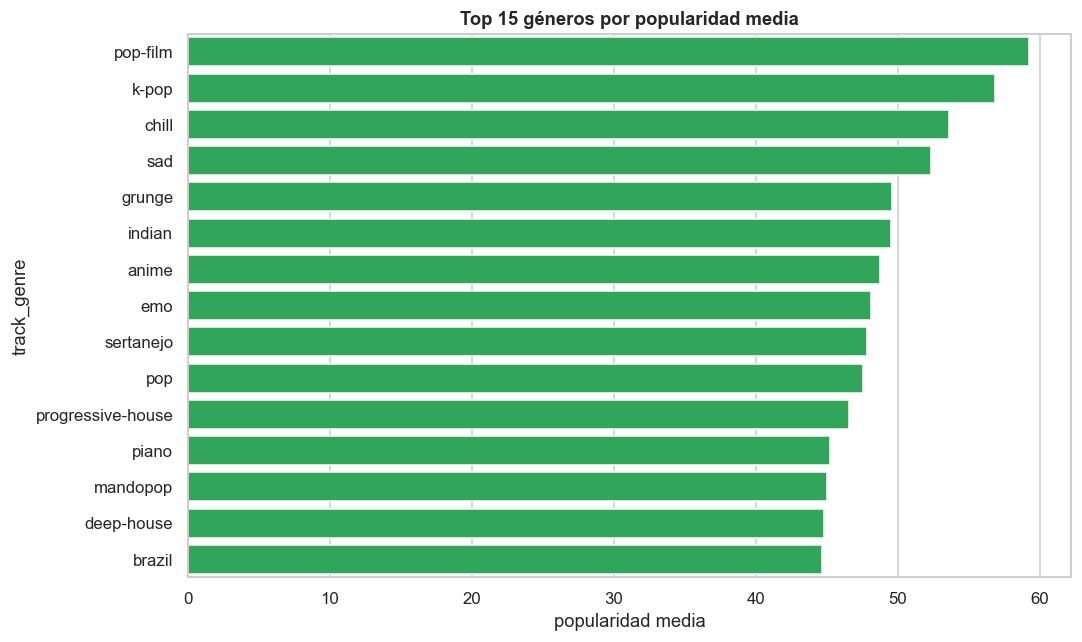

In [2]:
pop_g = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False)
top15 = pop_g.head(15)
print("Top 15 géneros por popularidad media:\n", top15.round(1).to_string())

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=top15.values, y=top15.index, ax=ax, color="#1DB954")
ax.set_title("Top 15 géneros por popularidad media"); ax.set_xlabel("popularidad media")
fig.tight_layout(); fig.savefig(REPORTS/"05_popularity_by_genre.png", bbox_inches="tight"); plt.show()

## 2.2 Perfil de audio por género (radar)

Géneros comparados: ['pop', 'classical', 'metal', 'jazz', 'reggaeton']


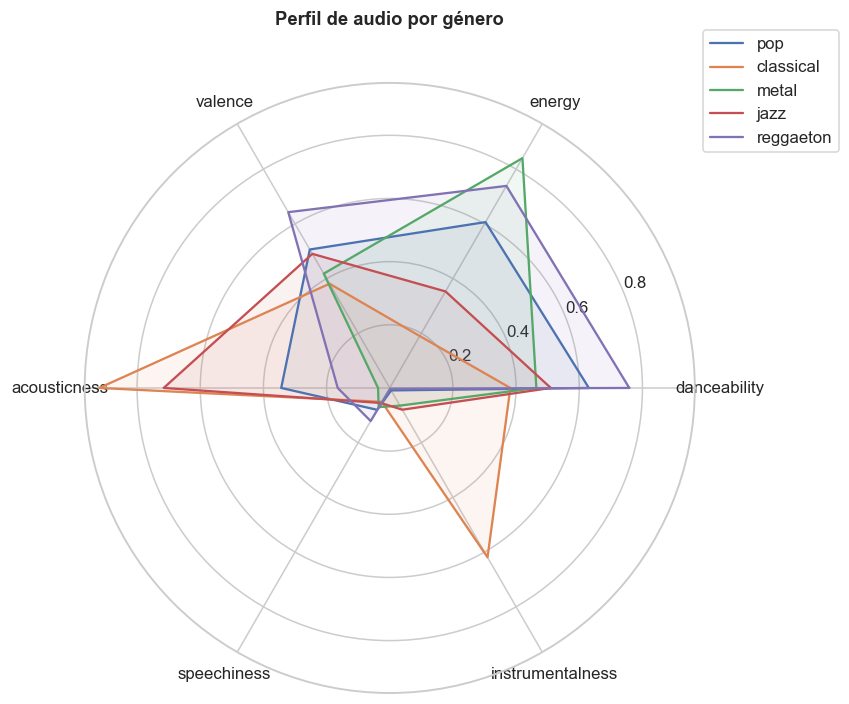

In [3]:
cand = ["pop","classical","metal","jazz","reggaeton","edm","acoustic","hip-hop"]
genres = [g for g in cand if g in df.track_genre.unique()][:5]
print("Géneros comparados:", genres)
prof = df[df.track_genre.isin(genres)].groupby("track_genre")[AUDIO].mean()

ang = np.linspace(0, 2*np.pi, len(AUDIO), endpoint=False).tolist(); ang += ang[:1]
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for g in genres:
    vals = prof.loc[g, AUDIO].tolist(); vals += vals[:1]
    ax.plot(ang, vals, label=g); ax.fill(ang, vals, alpha=0.08)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(AUDIO)
ax.set_title("Perfil de audio por género", y=1.08); ax.legend(loc="upper right", bbox_to_anchor=(1.25,1.1))
fig.tight_layout(); fig.savefig(REPORTS/"06_genre_audio_profile.png", bbox_inches="tight"); plt.show()

## 2.3 Heatmap géneros × features de audio

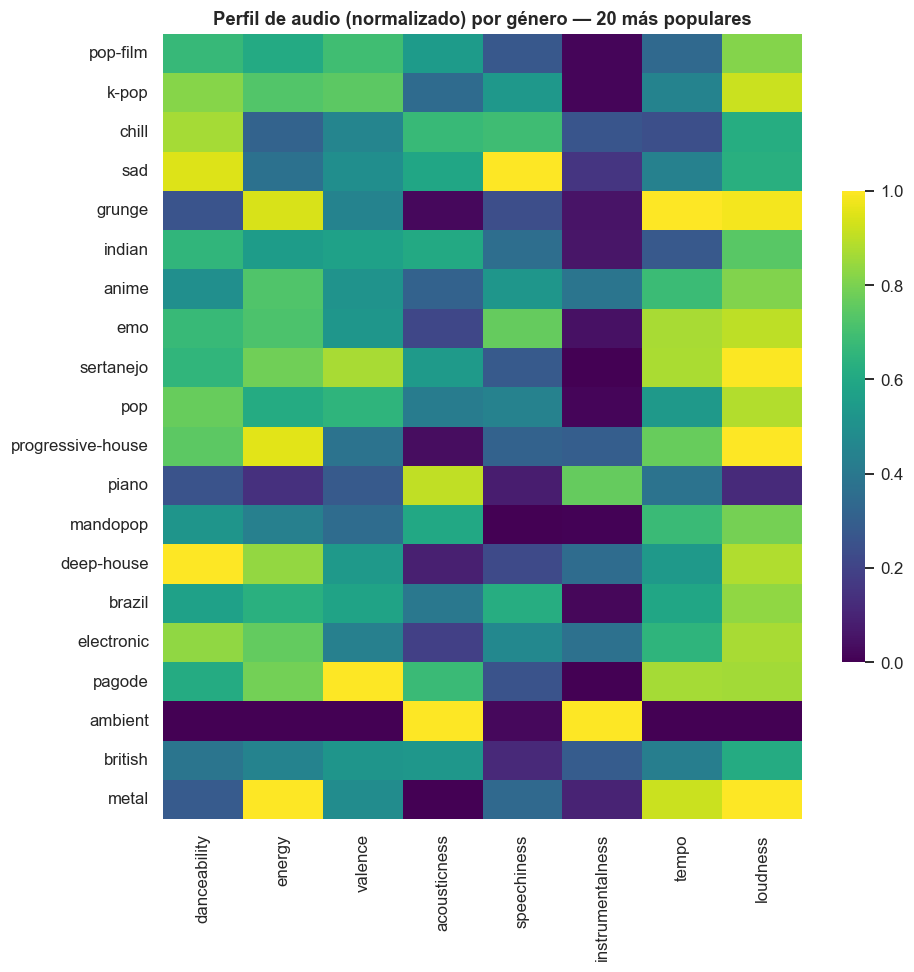

In [4]:
g_audio = df.groupby("track_genre")[AUDIO+["tempo","loudness"]].mean()
sel = g_audio.loc[pop_g.head(20).index]   # 20 géneros más populares
norm = (sel - sel.min()) / (sel.max() - sel.min())   # min-max por columna para comparar
fig, ax = plt.subplots(figsize=(9,9))
sns.heatmap(norm, cmap="viridis", ax=ax, cbar_kws={"shrink":.6})
ax.set_title("Perfil de audio (normalizado) por género — 20 más populares")
ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout(); fig.savefig(REPORTS/"07_genre_heatmap.png", bbox_inches="tight"); plt.show()

## Conclusiones

- Los géneros **sí tienen perfiles de audio diferenciados**: el radar separa claramente, p.ej.,
  classical (alta acousticness/instrumentalness) de metal/edm (alta energy).
- La popularidad media varía fuerte entre géneros — la popularidad es más cuestión de **género y
  contexto** que de las features de audio aisladas (consistente con la Fase 1).
- ⚠️ El dataset **no tiene año de lanzamiento**, así que el análisis de evolución temporal
  (Fase 2.4 del roadmap) no es aplicable.

➡️ **Siguiente:** `03_clustering.ipynb` — agrupar canciones por "vibes" sin usar el género.